# Imports kaggle into enviorment

In [1]:
import os
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# 2.Clears old data


In [ ]:
!rm -rf /content/data /content/intel-image-classification.zip

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:03<00:00, 109MB/s]



In [ ]:
!ls /content/data
!ls /content/data/seg_train

seg_pred  seg_test  seg_train
seg_train


In [ ]:
!ls /content/data/seg_train/seg_train

buildings  forest  glacier  mountain  sea  street


# Class Counts

In [ ]:
import os

train_dir = '/content/data/seg_train/seg_train'
counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in os.listdir(train_dir)}
print(counts)

{'mountain': 2512, 'sea': 2274, 'forest': 2271, 'glacier': 2404, 'street': 2382, 'buildings': 2191}


# Check image size

In [ ]:
from PIL import Image
import os

sample_class = os.listdir(train_dir)[0]
sample_folder = os.path.join(train_dir, sample_class)
sample_files = os.listdir(sample_folder)[:5]

for f in sample_files:
    img = Image.open(os.path.join(sample_folder, f))
    print(f, img.size)

415.jpg (150, 150)
16983.jpg (150, 150)
2168.jpg (150, 150)
12177.jpg (150, 150)
2531.jpg (150, 150)


# Visual sanity check so that only one image per class

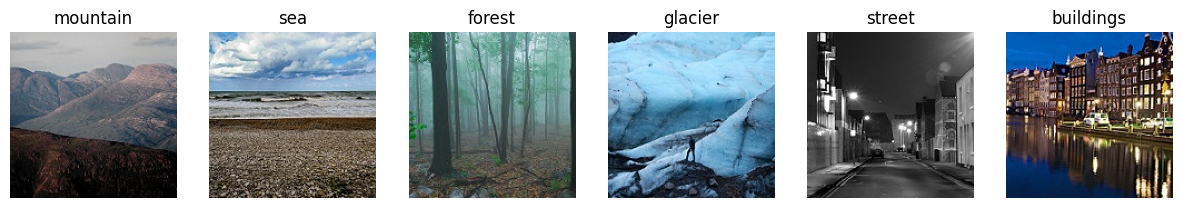

In [ ]:
import matplotlib.pyplot as plt

classes = os.listdir(train_dir)
fig, axes = plt.subplots(1, len(classes), figsize=(15, 3))

for ax, cls in zip(axes, classes):
    cls_folder = os.path.join(train_dir, cls)
    img_path = os.path.join(cls_folder, os.listdir(cls_folder)[0])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.show()

# Class Distribution bar chart(for better visual representation of data)

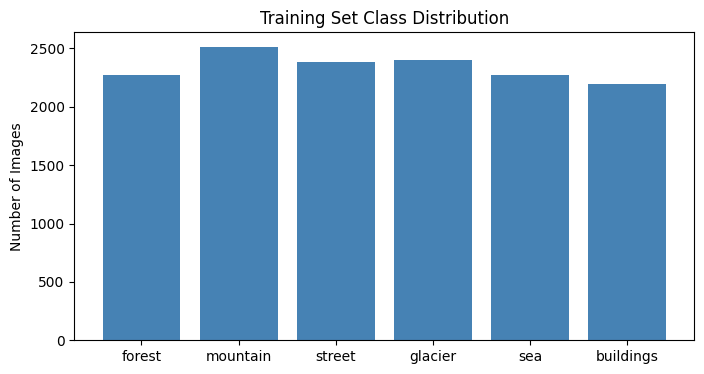

In [ ]:
# Class distribution bar chart
import matplotlib.pyplot as plt
counts = {'forest': 2271, 'mountain': 2512, 'street': 2382, 'glacier': 2404, 'sea': 2274, 'buildings': 2191}
plt.figure(figsize=(8,4))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.ylabel('Number of Images')
plt.title('Training Set Class Distribution')
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy test

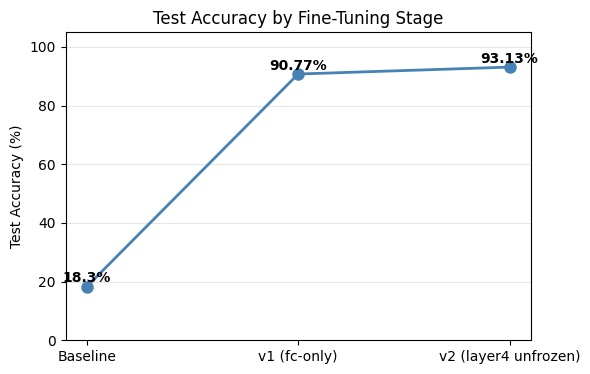

In [ ]:
# Accuracy progression line chart
import matplotlib.pyplot as plt

stages = ['Baseline', 'v1 (fc-only)', 'v2 (layer4 unfrozen)']
accs = [18.30, 90.77, 93.13]

plt.figure(figsize=(6,4))
plt.plot(stages, accs, marker='o', color='steelblue', linewidth=2, markersize=8)
for i, v in enumerate(accs):
    plt.text(i, v+1.5, f'{v}%', ha='center', fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy by Fine-Tuning Stage')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.savefig('accuracy_progression.png', dpi=300, bbox_inches='tight')
plt.show()

# Data Pipeline

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='/content/data/seg_train/seg_train', transform=transform)
test_dataset = datasets.ImageFolder(root='/content/data/seg_test/seg_test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(train_dataset.classes)
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train size: 14034, Test size: 3000


# Loading pretrained ResNet18 and baseline accuracy

In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = models.resnet18(weights='IMAGENET1K_V1')
model = model.to(device)
model.eval()

cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Freeze early layers

In [ ]:
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 6)
model = model.to(device)

# Aspect ratio layer

In [ ]:
import os

from PIL import Image

def get_orientation(img_path, threshold=1.0):
    img = Image.open(img_path)
    width, height = img.size
    ratio = width / height
    if ratio > threshold:
        return 'horizontal'
    elif ratio < 1 / threshold:
        return 'vertical'
    else:
        return 'square'

results = []

for cls in os.listdir(train_dir):
    cls_folder = os.path.join(train_dir, cls)
    for f in os.listdir(cls_folder):
        path = os.path.join(cls_folder, f)
        orientation = get_orientation(path)
        results.append({'path': path, 'category': cls, 'orientation': orientation})

print(results[:5])  # peek at the first few

[{'path': '/content/data/seg_train/seg_train/mountain/415.jpg', 'category': 'mountain', 'orientation': 'square'}, {'path': '/content/data/seg_train/seg_train/mountain/16983.jpg', 'category': 'mountain', 'orientation': 'square'}, {'path': '/content/data/seg_train/seg_train/mountain/2168.jpg', 'category': 'mountain', 'orientation': 'square'}, {'path': '/content/data/seg_train/seg_train/mountain/12177.jpg', 'category': 'mountain', 'orientation': 'square'}, {'path': '/content/data/seg_train/seg_train/mountain/2531.jpg', 'category': 'mountain', 'orientation': 'square'}]


# Test if on cpu or gpu

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


# Imports and loading ResNet18

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = models.resnet18(weights='IMAGENET1K_V1')
model = model.to(device)
model.eval()

cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# More layers freezing and final layer

In [ ]:
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 6)
model = model.to(device)

# Re-Downloading Data Set

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'paste_your_token_here'

!kaggle datasets download -d puneet6060/intel-image-classification --force
!unzip -o -q intel-image-classification.zip -d /content/data
!ls /content/data/seg_train

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:03<00:00, 104MB/s]

seg_train


# Data Pipeline

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='/content/data/seg_train/seg_train', transform=transform)
test_dataset = datasets.ImageFolder(root='/content/data/seg_test/seg_test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Baseline Evaluation/Pre fine-tuning

In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

baseline_accuracy = 100 * correct / total
print(f"Baseline accuracy (no fine-tuning): {baseline_accuracy:.2f}%")

Baseline accuracy (no fine-tuning): 26.23%


# Actual Fine-Tuning Training Loop

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {running_loss/len(train_loader):.4f} — Train Accuracy: {epoch_acc:.2f}%")

Epoch 1/3 — Loss: 0.4908 — Train Accuracy: 83.45%
Epoch 2/3 — Loss: 0.3055 — Train Accuracy: 89.21%
Epoch 3/3 — Loss: 0.2878 — Train Accuracy: 89.69%


# Fine-tuned evaluation

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fine_tuned_accuracy = 100 * correct / total
print(f"Fine-tuned accuracy (test set): {fine_tuned_accuracy:.2f}%")
print(f"Improvement over baseline: {fine_tuned_accuracy - baseline_accuracy:.2f} percentage points")

Fine-tuned accuracy (test set): 89.90%
Improvement over baseline: 63.67 percentage points


# Confusion Matrix V2

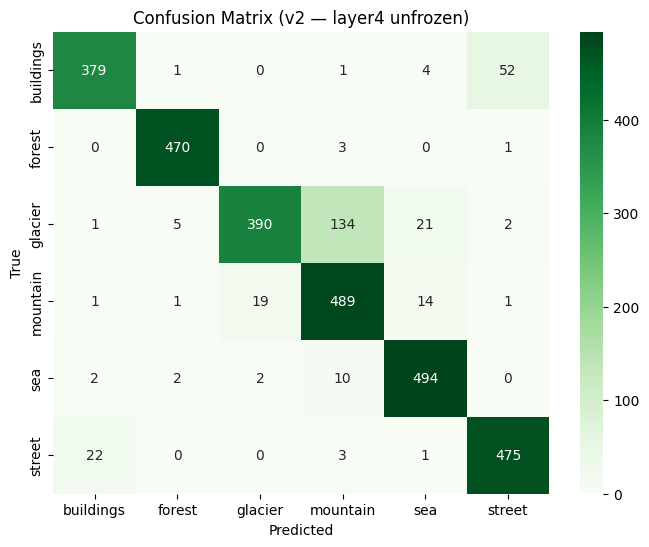

              precision    recall  f1-score   support

   buildings       0.94      0.87      0.90       437
      forest       0.98      0.99      0.99       474
     glacier       0.95      0.71      0.81       553
    mountain       0.76      0.93      0.84       525
         sea       0.93      0.97      0.95       510
      street       0.89      0.95      0.92       501

    accuracy                           0.90      3000
   macro avg       0.91      0.90      0.90      3000
weighted avg       0.91      0.90      0.90      3000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm_v2 = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm_v2, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (v2 — layer4 unfrozen)')
plt.savefig('confusion_matrix_v2.png', dpi=300, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

# Save Model weights

In [ ]:
torch.save(model.state_dict(), '/content/picsort_model.pth')

from google.colab import files
files.download('/content/picsort_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Confusion matrix

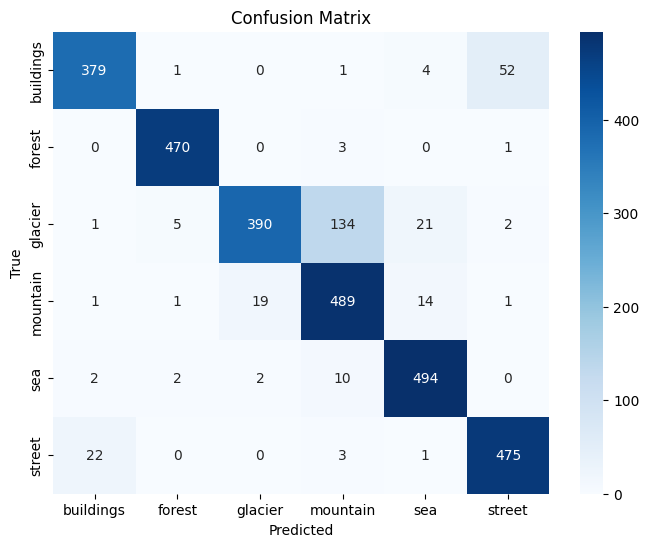

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Per-Class recall function

In [ ]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.94      0.87      0.90       437
      forest       0.98      0.99      0.99       474
     glacier       0.95      0.71      0.81       553
    mountain       0.76      0.93      0.84       525
         sea       0.93      0.97      0.95       510
      street       0.89      0.95      0.92       501

    accuracy                           0.90      3000
   macro avg       0.91      0.90      0.90      3000
weighted avg       0.91      0.90      0.90      3000



# Unfreezing layer 4(for more perecision)

In [ ]:
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

# More Fine-tuning for layer4 to npow run on new unfrozen parameters

In [ ]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {running_loss/len(train_loader):.4f} — Train Accuracy: {epoch_acc:.2f}%")

Epoch 1/3 — Loss: 0.2489 — Train Accuracy: 91.51%
Epoch 2/3 — Loss: 0.0883 — Train Accuracy: 96.89%
Epoch 3/3 — Loss: 0.0383 — Train Accuracy: 98.88%


# Fine Tuned evaluation

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fine_tuned_accuracy_v2 = 100 * correct / total
print(f"Fine-tuned accuracy v2 (layer4 unfrozen): {fine_tuned_accuracy_v2:.2f}%")
print(f"Improvement over v1 (fc only): {fine_tuned_accuracy_v2 - fine_tuned_accuracy:.2f} percentage points")

Fine-tuned accuracy v2 (layer4 unfrozen): 93.33%
Improvement over v1 (fc only): 3.43 percentage points
